# A single LISA glitch

[Open in Colab](https://colab.research.google.com/github/jaxglitches/jaxglitches/blob/main/docs/examples/quickstart.ipynb)

Build equal-arm TDI-2 waveforms in time and frequency, then differentiate the
Fourier response with JAX. Synthetic signals only; no external data or sampler.

## Setup

Run this install cell in Colab or a fresh Python 3.12+ environment. For a local
checkout, use `uv sync --locked --group examples` instead. The docs build skips
this installation cell and uses its already installed package.

In [ ]:
! pip install "jaxglitches @ git+https://github.com/jaxglitches/jaxglitches.git" matplotlib

In [1]:
%matplotlib inline
import jax
import jax.numpy as jnp
import jaxglitches as jg
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (7, 3.5), "font.size": 11})

## Build the responses

Use a 600 s window with 0.5 s sampling. Parameters are onset `t0=120 s`,
velocity kick `Deltav=1.2e-13 m/s`, and decay time `tau=5 s`.
Both responses use TDI-2 and AET channels.

In [2]:
t_obs, dt = 600.0, 0.5
t0, delta_v, tau = 120.0, 1.2e-13, 5.0
params = jnp.array([t0, delta_v, tau])
time = jnp.arange(0.0, t_obs, dt)
freq = jg.freq_grid(t_obs=t_obs, dt=dt)
h_time = jg.clean_signal_t(params, time, tdi=2, basis="AET")
h_freq = jg.clean_signal_f(params, freq, tdi=2, basis="AET")
print(f"Time response: {h_time.shape}; Fourier response: {h_freq.shape}")

Time response: (1200, 3); Fourier response: (601, 3)


## View the glitch

The time response is fractional frequency; the analytic Fourier transform has
units of seconds. This is the noiseless response, not a noise PSD.

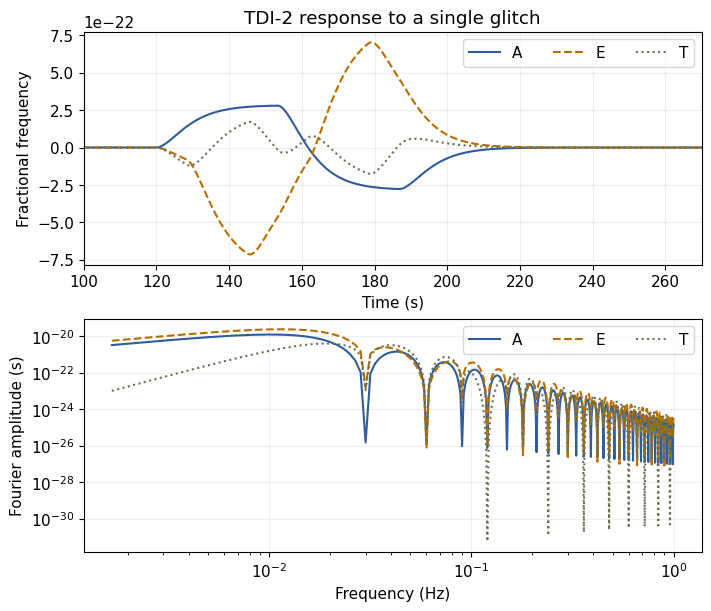

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), layout="constrained")
for column, (channel, color, style) in enumerate(
    zip("AET", ["#305c9c", "#b76e00", "#6a7150"], ["-", "--", ":"])
):
    axes[0].plot(time, h_time[:, column], label=channel, color=color, linestyle=style)
    axes[1].loglog(freq[1:], np.abs(h_freq[1:, column]),
                   label=channel, color=color, linestyle=style)
axes[0].set(xlim=(t0 - 20, t0 + 150), xlabel="Time (s)",
            ylabel="Fractional frequency", title="TDI-2 response to a single glitch")
axes[1].set(xlabel="Frequency (Hz)", ylabel="Fourier amplitude (s)")
for ax in axes:
    ax.legend(ncols=3)
    ax.grid(alpha=0.2)
plt.show()

## Differentiate and check

The Jacobian has shape `(frequency bins, channels, parameters)`, with parameter
order `[t0, Deltav, tau]`. These checks confirm shapes, finite values, and the
zero DC response. They do not test inference or recovery from noisy data.

In [4]:
jacobian = jax.jacfwd(
    lambda p: jg.clean_signal_f(p, freq, tdi=2, basis="AET")
)(params)
assert h_time.shape == (1200, 3)
assert h_freq.shape == (601, 3)
assert jacobian.shape == (601, 3, 3)
assert bool(jnp.all(jnp.isfinite(h_time)))
assert bool(jnp.all(jnp.isfinite(h_freq)))
assert bool(jnp.all(jnp.isfinite(jacobian)))
assert bool(jnp.all(h_freq[0] == 0))
print(f"Jacobian: {jacobian.shape}; all checks passed.")

Jacobian: (601, 3, 3); all checks passed.


## Next steps

Change `tau` or the TDI generation and rerun. For likelihoods or unequal arms,
see the [API reference](https://jaxglitches.github.io/jaxglitches/api/) and
[conventions](https://jaxglitches.github.io/jaxglitches/conventions/).